# CosmoHydro Emulator - Basic Usage Examples

This notebook demonstrates how to use the `cosmohydro_emu` package to make multi-redshift predictions for summary statistics of the CRK-HACC CosmoHydro suite (5 subgrid + 2 cosmology parameters).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from cosmohydro_emu import (
    load_emulator,
    list_available_statistics,
    get_x_grid,
    get_redshifts,
    get_plot_info,
    get_parameter_info,
    get_statistic_info,
    FIDUCIAL_COSMOLOGY,
)

FIG_DIR = '../docs/assets'
os.makedirs(FIG_DIR, exist_ok=True)

## 1. Input parameters

All 7-parameter emulators take `[kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps_kin/1e1, omega_m, sigma_8]` in the scaled units below. The gravity-only emulator takes only `[omega_m, sigma_8]`.

In [2]:
param_info = get_parameter_info()

md = '| # | Parameter | Symbol | Range | Description |\n|---|---|---|---|---|\n'
for i, name in enumerate(param_info['names']):
    md += (f"| {i+1} | `{name}` | {param_info['latex_names'][i]} | "
           f"{param_info['ranges'][name]} | {param_info['descriptions'][name]} |\n")
display(Markdown(md))
print('Fiducial cosmology:', FIDUCIAL_COSMOLOGY)

| # | Parameter | Symbol | Range | Description |
|---|---|---|---|---|
| 1 | `kappa_w` | $\kappa_\mathrm{w}$ | (2.0, 4.0) | AGN wind coupling / wind efficiency parameter |
| 2 | `e_w` | $e_\mathrm{w}$ | (0.2, 1.0) | AGN energy efficiency / wind energy fraction |
| 3 | `M_seed` | $M_\mathrm{seed}/10^{6}$ | (0.6, 2.0) | Black hole seed mass (in 10^6 M_sun) |
| 4 | `v_kin` | $v_\mathrm{kin}/10^{4}$ | (0.1, 1.2) | Kinetic feedback velocity (in 10^4 km/s) |
| 5 | `epsilon_kin` | $\epsilon_\mathrm{kin}/10^{1}$ | (0.02, 1.2) | Kinetic feedback efficiency (in 10^1) |
| 6 | `omega_m` | $\omega_\mathrm{m}$ | (0.12, 0.155) | Physical matter density omega_m = Omega_m h^2 |
| 7 | `sigma_8` | $\sigma_8$ | (0.7, 0.9) | Amplitude of matter fluctuations |


Fiducial cosmology: {'omega_m': 0.14176, 'sigma_8': 0.8102}


## 2. Available statistics and their redshift coverage

In [3]:
stats = list_available_statistics()
info = get_statistic_info()

md = '| stat_name | Category | Description | Quantity | # params | Redshifts |\n|---|---|---|---|---|---|\n'
for cat, names in stats.items():
    for s in names:
        z = info[s]['redshifts']
        zstr = ', '.join(f'{v:.2f}' for v in z) if len(z) <= 5 else f'{len(z)} snapshots, z = {z.min():.1f} - {z.max():.1f}'
        md += (f"| `{s}` | {cat} | {info[s]['title']} | {get_plot_info(s)['ylabel'].replace('|', chr(92)+'|')} | "
               f"{info[s]['n_params']} | {zstr} |\n")
display(Markdown(md))

| stat_name | Category | Description | Quantity | # params | Redshifts |
|---|---|---|---|---|---|
| `GSMF` | summary | Galaxy stellar mass function | $\mathrm{d}n \, / \, \mathrm{d}\log_{10} M_{\ast} \; [(h^{-1}\mathrm{Mpc})^{-3}]$ | 7 | 11 snapshots, z = 0.0 - 2.0 |
| `HMF` | summary | Halo mass function | $\mathrm{d}n / \mathrm{d}\log_{10} M \; [(h^{-1}\mathrm{Mpc})^{-3}]$ | 7 | 11 snapshots, z = 0.0 - 2.0 |
| `fGas` | summary | Cluster gas fraction | $M_{\mathrm{gas}} / M_{\mathrm{500c}} \quad [<R_{\mathrm{500c}}]$ | 7 | 7 snapshots, z = 0.0 - 1.0 |
| `Pk-ratio` | summary | Matter power spectrum suppression | $P_{\mathrm{hydro}}(k)\,/\,P_{\mathrm{grav}}(k)$ | 7 | 0.00, 0.10, 0.50, 1.00, 2.00 |
| `CSFR` | summary | Cosmic star formation rate | $\mathrm{CSFR} \, [\mathrm{M}_{\odot} \, \mathrm{yr}^{-1} \, (h^{-1}\mathrm{Mpc})^{-3}]$ | 7 | 0.00 |
| `CGD` | profile | Cluster gas density profile | $\rho_{\mathrm{gas}} \,/\, \rho_{\mathrm{crit}}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CGED` | profile | Cluster gas electron density profile | $n_{\mathrm{e}}$ [$\mathrm{cm}^{-3}$] | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CPP` | profile | Cluster gas pressure profile | $P / P_{\mathrm{500}}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CTP` | profile | Cluster gas temperature profile | $T / T_{\mathrm{500}}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CEP` | profile | Cluster gas entropy profile | $K / K_{\mathrm{500}}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CEEP` | profile | Cluster electron entropy profile | $K_{\mathrm{e}} / K_{\mathrm{500}}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CMP` | profile | Cluster gas metallicity profile | $Z / Z_{\odot}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `CYP` | profile | Cluster Compton-y profile | $y_{\mathrm{SZ}}$ | 7 | 0.00, 0.10, 0.25, 0.30, 0.50 |
| `Pk_GO` | gravity_only | Gravity-only matter power spectrum | $P_{\mathrm{grav}}(k) \, [(h^{-1}\mathrm{Mpc})^{3}]$ | 2 | 0.00, 0.10, 0.50, 1.00, 2.00 |


## 3. A single prediction

`predict` returns the mean and the Gaussian-process standard deviation on the statistic's x-grid, at any redshift inside the trained range (linearly interpolated between snapshots).

In [4]:
# [kappa_w, e_w, M_seed/1e6, v_kin/1e4, eps_kin/1e1, omega_m, sigma_8]
params = np.array([3.0, 0.5, 1.0, 0.65, 0.5, FIDUCIAL_COSMOLOGY['omega_m'], FIDUCIAL_COSMOLOGY['sigma_8']])

emu = load_emulator('GSMF')
print(emu)

mean, std = emu.predict(params, z=0.3)
x_grid, x_label = get_x_grid('GSMF')
print('x-grid:', x_label, x_grid.shape, ' prediction:', mean.shape)

CosmoHydroEmulator(stat_name='GSMF', n_params=7, redshifts=[0.0, 0.1, 0.251, 0.3, 0.499, 0.749, 1.0, 1.25, 1.501, 1.753, 2.004])
x-grid: Stellar mass [$M_\odot$] (16,)  prediction: (16,)


## 4. All summary statistics at z = 0

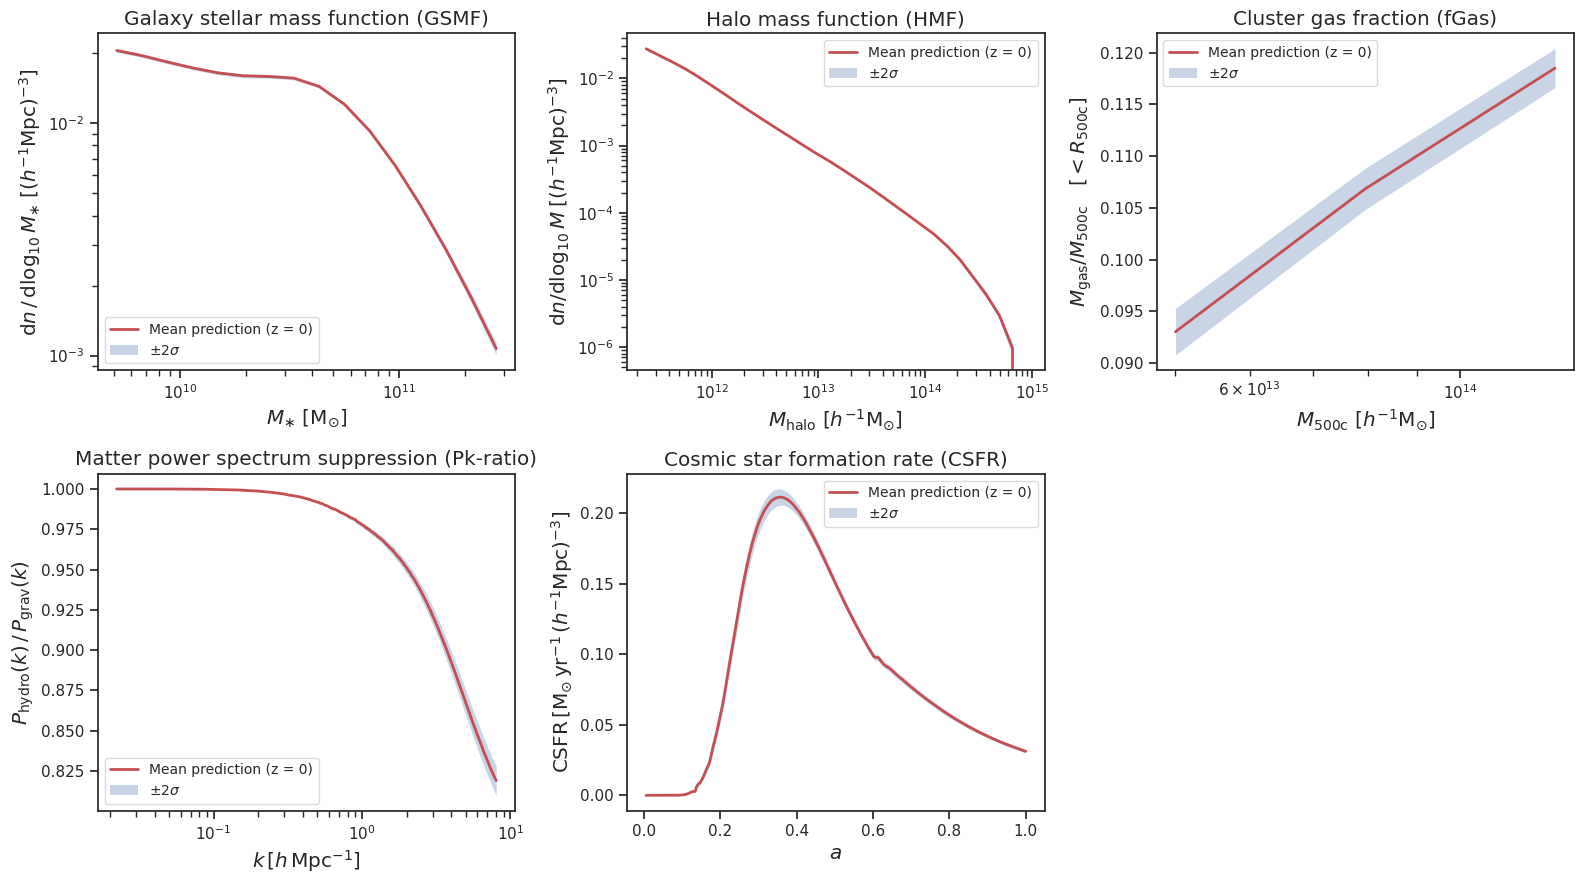

In [5]:
def plot_stat(ax, stat_name, params, z, color='C3'):
    emu = load_emulator(stat_name)
    p = params if emu.n_params == 7 else params[5:]
    mean, std = emu.predict(p, z=z)
    x_grid, _ = get_x_grid(stat_name)
    pi = get_plot_info(stat_name)
    ax.plot(x_grid, mean, '-', color=color, lw=2, label=f'Mean prediction (z = {z:g})')
    ax.fill_between(x_grid, mean - 2 * std, mean + 2 * std, alpha=0.3, color='C0', lw=0, label=r'$\pm 2\sigma$')
    ax.set_xscale(pi['xscale']); ax.set_yscale(pi['yscale'])
    ax.set_xlabel(pi['xlabel'], fontsize='large'); ax.set_ylabel(pi['ylabel'], fontsize='large')
    ax.set_title(f"{pi['title']} ({stat_name})", fontsize='large')
    return ax

summary_stats = stats['summary']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, s in zip(axes.flat, summary_stats):
    plot_stat(ax, s, params, z=0.0)
    ax.legend(fontsize='small', frameon=True, framealpha=0.7)
for ax in axes.flat[len(summary_stats):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/summary_statistics.png', dpi=110, bbox_inches='tight')
plt.show()

## 5. All cluster profiles at z = 0

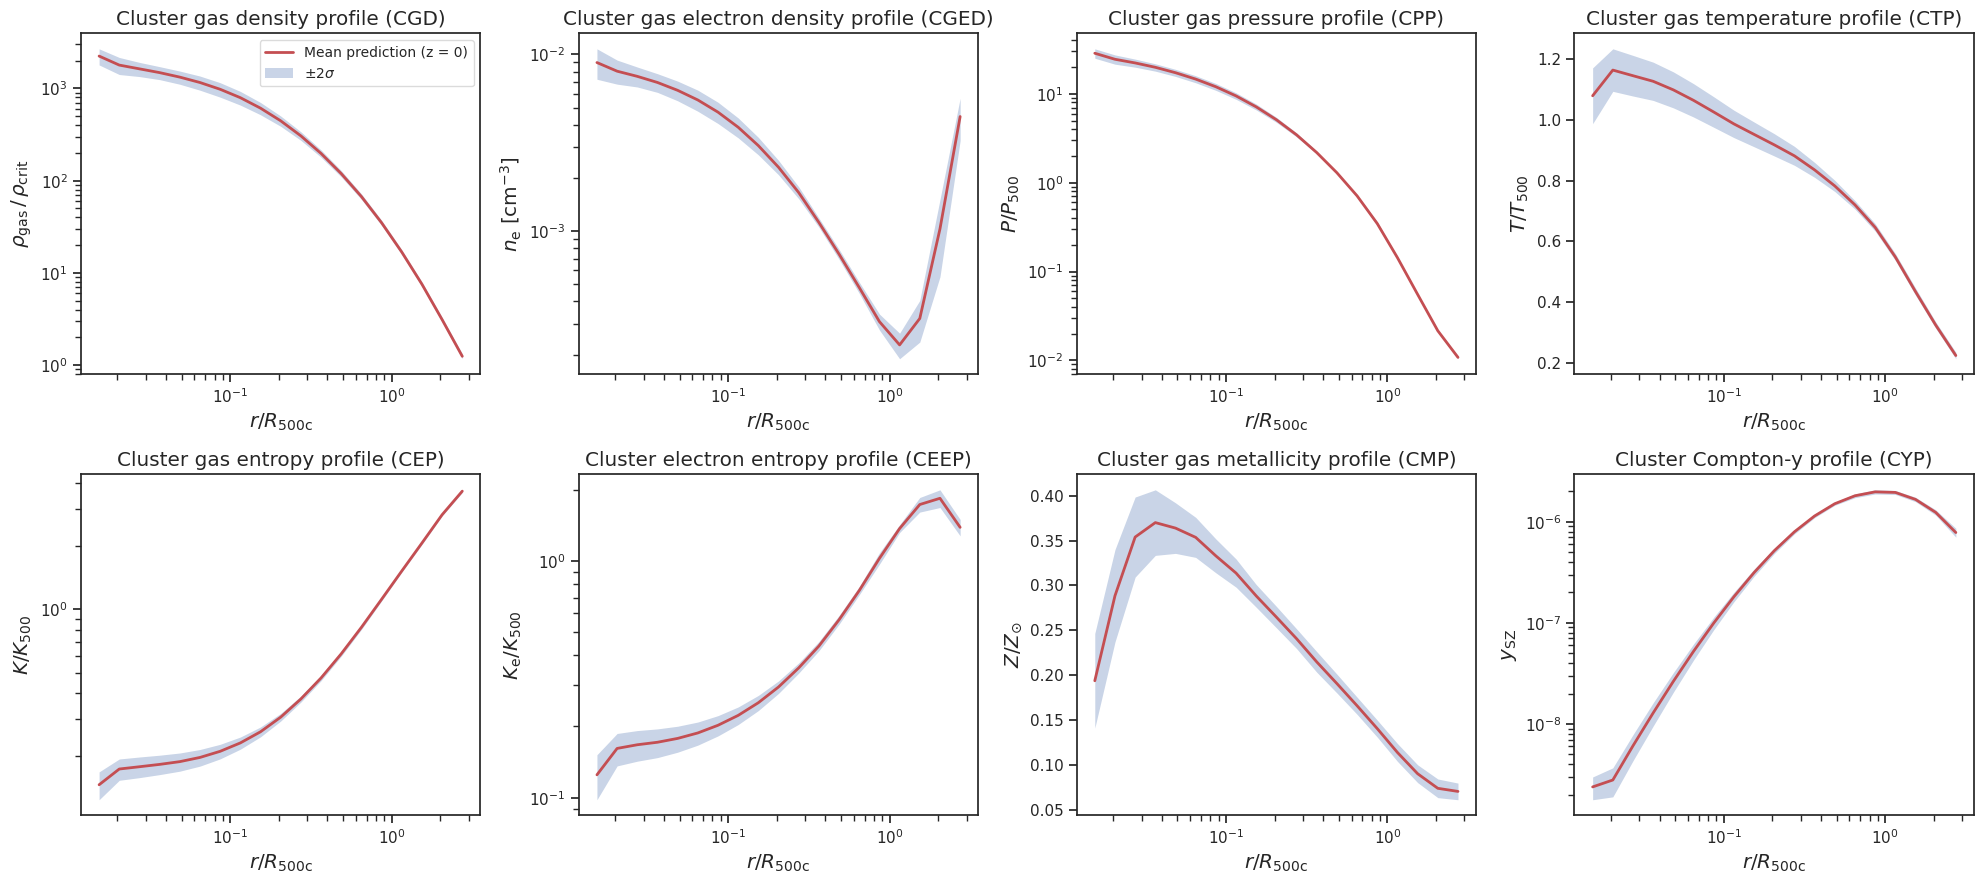

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, s in zip(axes.flat, stats['profile']):
    plot_stat(ax, s, params, z=0.0)
axes.flat[0].legend(fontsize='small', frameon=True, framealpha=0.7)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/cluster_profiles.png', dpi=110, bbox_inches='tight')
plt.show()

## 6. Redshift evolution

Each emulator knows its trained snapshots (`emu.redshifts`); any `z` in `emu.z_range` is allowed.

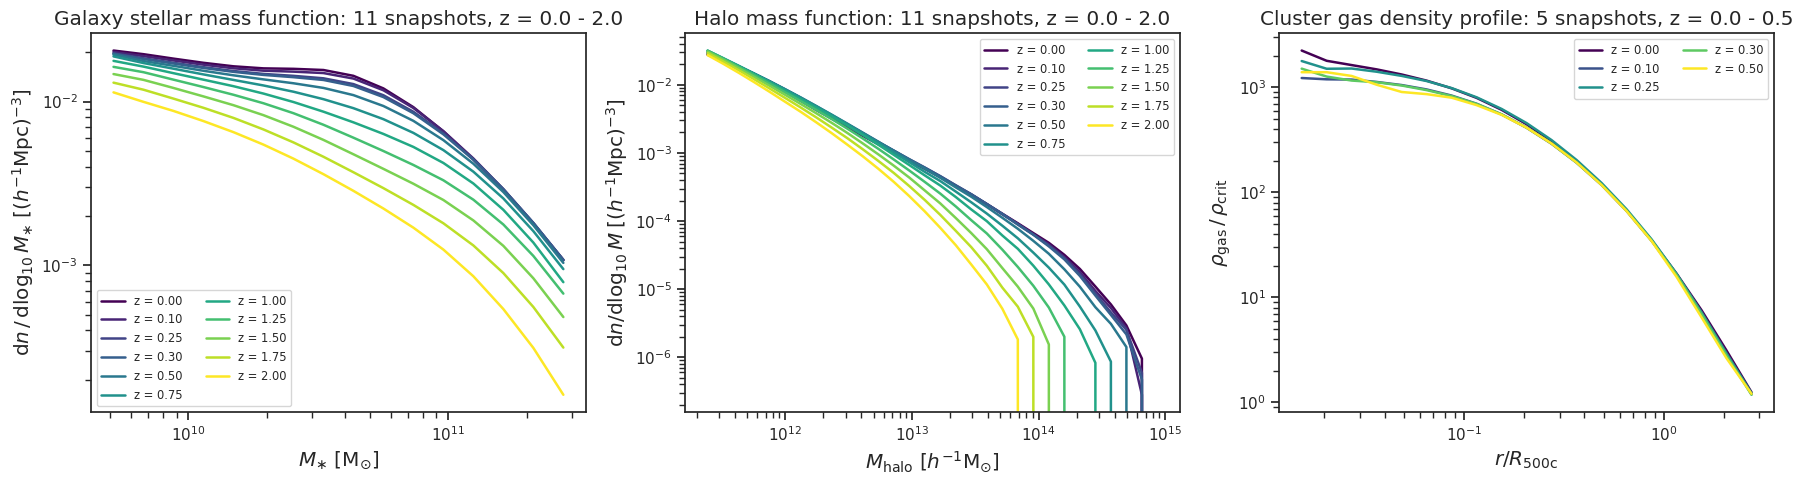

In [7]:
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, s in zip(axes, ['GSMF', 'HMF', 'CGD']):
    emu = load_emulator(s)
    x_grid, _ = get_x_grid(s); pi = get_plot_info(s)
    zs = emu.redshifts
    colors = cm.viridis(np.linspace(0, 1, len(zs)))
    for z, c in zip(zs, colors):
        mean, _ = emu.predict(params, z=z)
        ax.plot(x_grid, mean, color=c, lw=1.8, label=f'z = {z:.2f}')
    ax.set_xscale(pi['xscale']); ax.set_yscale(pi['yscale'])
    ax.set_xlabel(pi['xlabel'], fontsize='large'); ax.set_ylabel(pi['ylabel'], fontsize='large')
    ax.set_title(f"{pi['title']}: {len(zs)} snapshots, z = {zs.min():.1f} - {zs.max():.1f}", fontsize='large')
    ax.legend(fontsize='x-small', ncol=2)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/redshift_evolution.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Power spectra at interpolated redshifts

Predictions at redshifts between trained snapshots are linear interpolations of the two bracketing snapshot emulators (mean and standard deviation).

Two power-spectrum emulators are shipped: the baryonic suppression ratio `Pk-ratio` = $P_{\rm hydro}/P_{\rm grav}$ (7 parameters) and the gravity-only spectrum `Pk_GO` = $P_{\rm grav}$ (cosmology only). The full-hydro matter power spectrum is **not emulated directly** - it is the product of the two,

$$P_{\rm hydro}(k, z) = \left[\frac{P_{\rm hydro}}{P_{\rm grav}}\right](k, z) \times P_{\rm grav}(k, z),$$

which is how it enters the likelihood in the CosmoHydro inference (e.g. against KiDS-Legacy $P_m$ at $z_{\rm fid} = 0.15,\, 0.45$). Uncertainties are combined in quadrature.

Trained snapshots: [0.  0.1 0.5 1.  2. ]


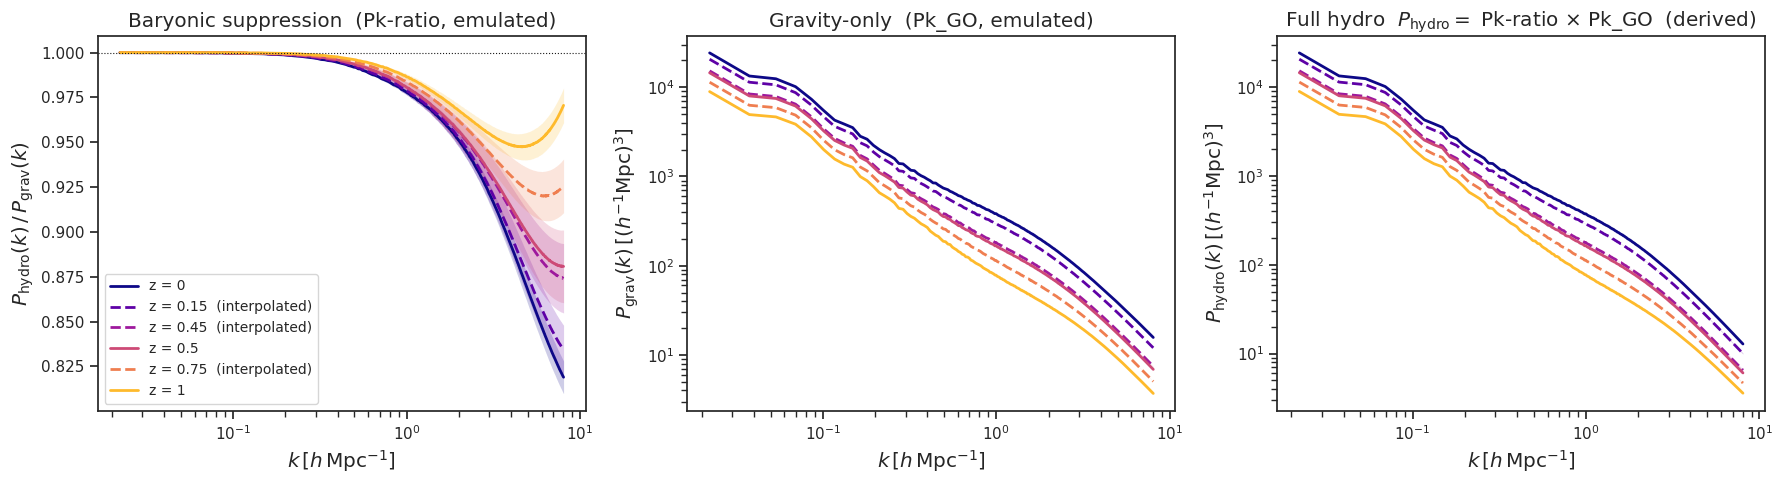

In [8]:
emu_ratio = load_emulator('Pk-ratio')
emu_go = load_emulator('Pk_GO')
k, _ = get_x_grid('Pk-ratio')
assert np.allclose(k, get_x_grid('Pk_GO')[0])          # same k-grid
print('Trained snapshots:', np.round(emu_ratio.redshifts, 2))

def pk_hydro(params, z):
    """P_hydro = (P_hydro/P_grav) x P_grav, with GP errors propagated in quadrature."""
    ratio, ratio_std = emu_ratio.predict(params, z=z)
    p_go, p_go_std = emu_go.predict(params[5:], z=z)
    p_hyd = ratio * p_go
    p_hyd_std = np.sqrt((ratio * p_go_std) ** 2 + (p_go * ratio_std) ** 2)
    return p_hyd, p_hyd_std

# trained snapshots (solid) and interpolated redshifts (dashed), incl. the KiDS-Legacy z_fid values
z_list = [(0.0, '-'), (0.15, '--'), (0.5, '-'), (0.45, '--'), (0.75, '--'), (1.0, '-')]
z_list = sorted(z_list)
colors = cm.plasma(np.linspace(0, 0.85, len(z_list)))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (z, ls), c in zip(z_list, colors):
    lab = f'z = {z:g}' + ('  (interpolated)' if ls == '--' else '')
    ratio, ratio_std = emu_ratio.predict(params, z=z)
    p_go, p_go_std = emu_go.predict(params[5:], z=z)
    p_hyd, p_hyd_std = pk_hydro(params, z)
    for ax, y, s in zip(axes, [ratio, p_go, p_hyd], [ratio_std, p_go_std, p_hyd_std]):
        ax.plot(k, y, ls, color=c, lw=2, label=lab)
        ax.fill_between(k, y - 2 * s, y + 2 * s, color=c, alpha=0.2, lw=0)

pi_ratio, pi_go = get_plot_info('Pk-ratio'), get_plot_info('Pk_GO')
axes[0].axhline(1, color='k', lw=0.8, ls=':')
axes[0].set_ylabel(pi_ratio['ylabel'], fontsize='large'); axes[0].set_title('Baryonic suppression  (Pk-ratio, emulated)', fontsize='large')
axes[1].set_yscale('log'); axes[1].set_ylabel(pi_go['ylabel'], fontsize='large'); axes[1].set_title('Gravity-only  (Pk_GO, emulated)', fontsize='large')
axes[2].set_yscale('log'); axes[2].set_ylabel(r'$P_{\mathrm{hydro}}(k) \, [(h^{-1}\mathrm{Mpc})^{3}]$', fontsize='large')
axes[2].set_title(r'Full hydro  $P_{\rm hydro} = $ Pk-ratio $\times$ Pk_GO  (derived)', fontsize='large')
for ax in axes:
    ax.set_xscale('log'); ax.set_xlabel(pi_ratio['xlabel'], fontsize='large')
axes[0].legend(fontsize='small')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/power_spectra.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Parameter variation study

Vary one subgrid parameter and one cosmological parameter at a time.

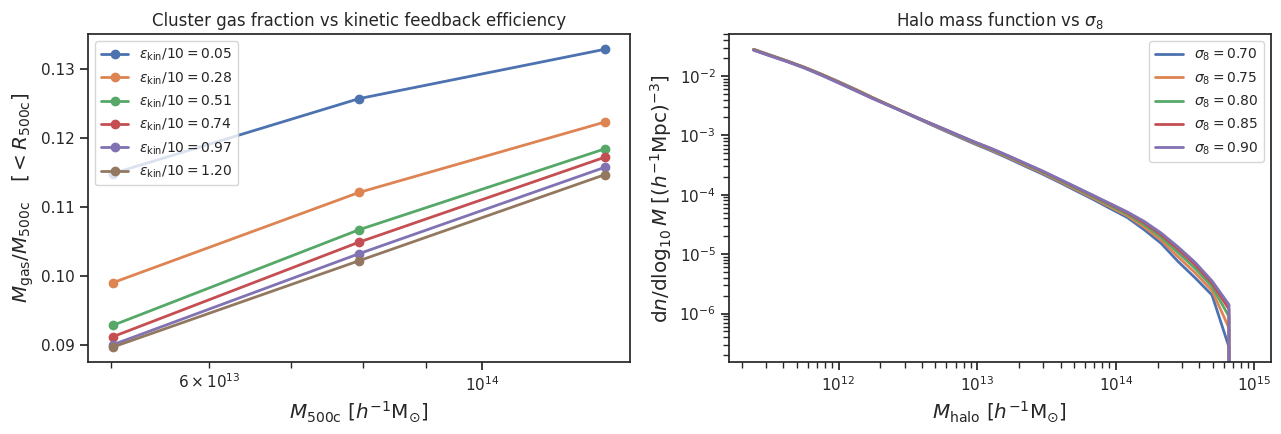

In [9]:
emu_fgas = load_emulator('fGas')
emu_hmf = load_emulator('HMF')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) fGas vs kinetic feedback efficiency
x_grid, _ = get_x_grid('fGas'); pi = get_plot_info('fGas')
for eps in np.linspace(0.05, 1.2, 6):
    p = params.copy(); p[4] = eps
    mean, _ = emu_fgas.predict(p, z=0.0)
    axes[0].plot(x_grid, mean, 'o-', lw=2, label=r'$\epsilon_\mathrm{kin}/10 = $' + f'{eps:.2f}')
axes[0].set_xscale(pi['xscale']); axes[0].set_xlabel(pi['xlabel'], fontsize='large'); axes[0].set_ylabel(pi['ylabel'], fontsize='large')
axes[0].set_title('Cluster gas fraction vs kinetic feedback efficiency'); axes[0].legend(fontsize='small')

# (b) HMF vs sigma_8
x_grid, _ = get_x_grid('HMF'); pi = get_plot_info('HMF')
for s8 in np.linspace(0.7, 0.9, 5):
    p = params.copy(); p[6] = s8
    mean, _ = emu_hmf.predict(p, z=0.0)
    axes[1].plot(x_grid, mean, lw=2, label=r'$\sigma_8 = $' + f'{s8:.2f}')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel(pi['xlabel'], fontsize='large'); axes[1].set_ylabel(pi['ylabel'], fontsize='large')
axes[1].set_title(r'Halo mass function vs $\sigma_8$'); axes[1].legend(fontsize='small')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/parameter_variation.png', dpi=110, bbox_inches='tight')
plt.show()

## 9. Batch predictions

Pass a `(n_pred, n_params)` array (and optionally one redshift per row) to predict many parameter sets in one call; the result has shape `(n_x, n_pred)`.

mean shape: (16, 8)  std shape: (16, 8)


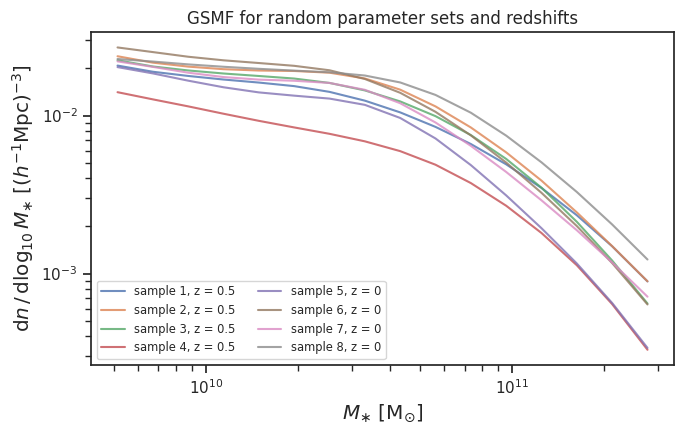

In [10]:
rng = np.random.default_rng(42)
ranges = np.array([param_info['ranges'][n] for n in param_info['names']])
params_batch = rng.uniform(ranges[:, 0], ranges[:, 1], size=(8, 7))
z_batch = rng.choice([0.0, 0.5, 1.0], size=8)

emu = load_emulator('GSMF')
mean, std = emu.predict(params_batch, z=z_batch)
print('mean shape:', mean.shape, ' std shape:', std.shape)

x_grid, _ = get_x_grid('GSMF'); pi = get_plot_info('GSMF')
fig, ax = plt.subplots(figsize=(7, 4.5))
for i in range(params_batch.shape[0]):
    ax.plot(x_grid, mean[:, i], lw=1.5, alpha=0.8, label=f'sample {i+1}, z = {z_batch[i]:g}')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel(pi['xlabel'], fontsize='large'); ax.set_ylabel(pi['ylabel'], fontsize='large')
ax.set_title('GSMF for random parameter sets and redshifts'); ax.legend(fontsize='x-small', ncol=2)
plt.tight_layout(); plt.show()